In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer   #converting text to numbers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os

#unziping
import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("archive")

fake_dataset = pd.read_csv("archive/Fake.csv")
true_dataset = pd.read_csv("archive/True.csv")

fake_dataset["label"] = 0   #fake label 0
true_dataset["label"] = 1   #true label 1

dataset = pd.concat([fake_dataset, true_dataset], axis=0)

dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)    #shuffing

dataset.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [7]:
print("Dataset Shape :", dataset.shape)

print("\nColumns types:" , dataset.columns)

print("\nLabel Distribution:\n")
print(dataset["label"].value_counts())

Dataset Shape : (44898, 5)

Columns types: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Label Distribution:

label
0    23481
1    21417
Name: count, dtype: int64


In [8]:
#combining the generated dataset
dataset["content"] = dataset["title"] + " " + dataset["text"]
dataset["content"].head()

X = dataset["content"]
y = dataset["label"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#removing too common english words and those appearing more than 70% doc
#as not used in detecting fake or real
vectorizer = TfidfVectorizer(stop_words = "english" , max_df = 0.7)

### always [training data: fit_transform()] [test data: transform()]
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)


(35918, 111683)


In [10]:
### LOGISTIC REGRESSION
#predicts probability that some thing belongs to a specific category 0/1
logistic_regression_model = LogisticRegression()

logistic_regression_model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [11]:
y_pred = logistic_regression_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy(How many articles were correctly classified) :", accuracy)

Accuracy(How many articles were correctly classified) : 0.984521158129176


In [12]:
print("Classification Report :\n")
print(classification_report(y_test, y_pred))

Classification Report :

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [13]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[4626   84]
 [  55 4215]]


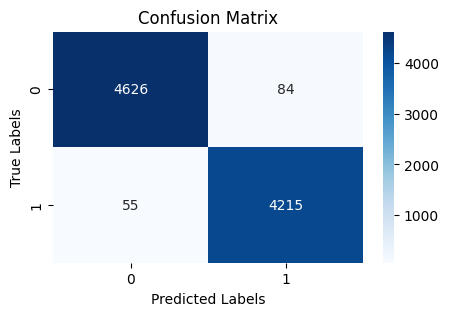

In [14]:
plt.figure(figsize=(5,3))

sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()

In [15]:
### NAIVE BAYES

from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

naive_bayes_predict = naive_bayes_model.predict(X_test_tfidf)

print(classification_report(y_test, naive_bayes_predict))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      4710
           1       0.94      0.92      0.93      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [16]:
### SVM (Support vector machine)
#finding a hyperplane that best seperate the 2 types within max margin too

from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predict = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, svm_predict))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

